<a href="https://colab.research.google.com/github/klshekhawat3027-web/week1_krishna_pal_singh_shekhawat/blob/main/Week2_krishna_pal_singh_shekhawat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# upload dataset
from google.colab import files
uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025 (3).csv to tesla_deliveries_dataset_2015_2025 (3).csv


In [27]:
import pandas as pd
import io

# File ko read karne ke liye (upload hone ke baad)
df = pd.read_csv(io.BytesIO(uploaded['tesla_deliveries_dataset_2015_2025 (3).csv']))

# Check karein ki data sahi se load hua ya nahi
print("Data successfully loaded!")
df.head()

Data successfully loaded!


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [28]:
import pandas as pd
import io

# 1. File ko load kiya
df = pd.read_csv(io.BytesIO(uploaded['tesla_deliveries_dataset_2015_2025 (3).csv']))

# 2. Shape aur columns check kiye
print("Rows aur Columns:")
print(df.shape)

print("\nColumns ke naam:")
print(df.columns)

# 3. Data ka basic info aur summary
print("\nData Info:")
df.info()

print("\nData Describe:")
print(df.describe())

# 4. Missing values aur duplicates check kiye
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows aur Columns:
(2640, 12)

Columns ke naam:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null  

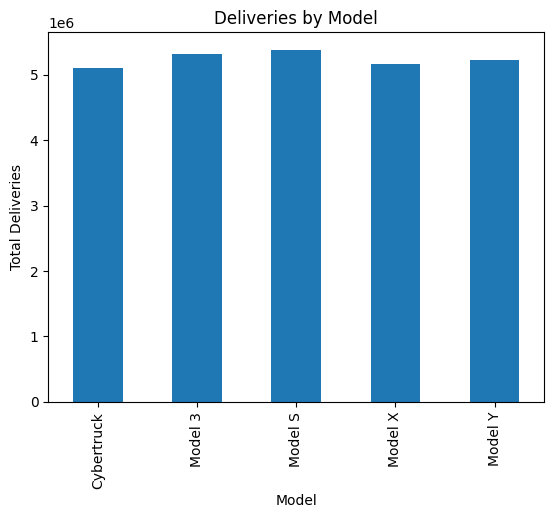

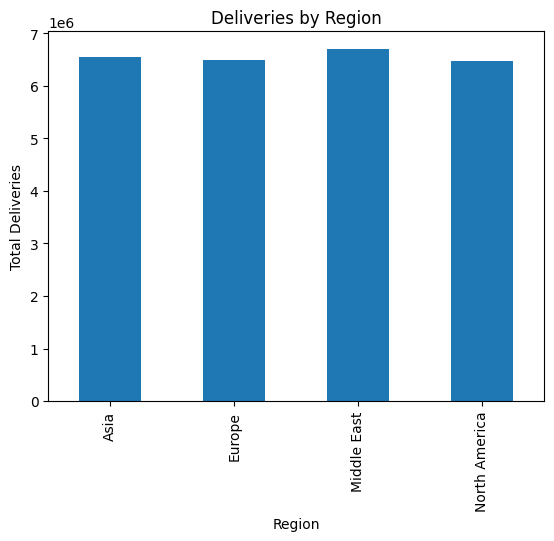

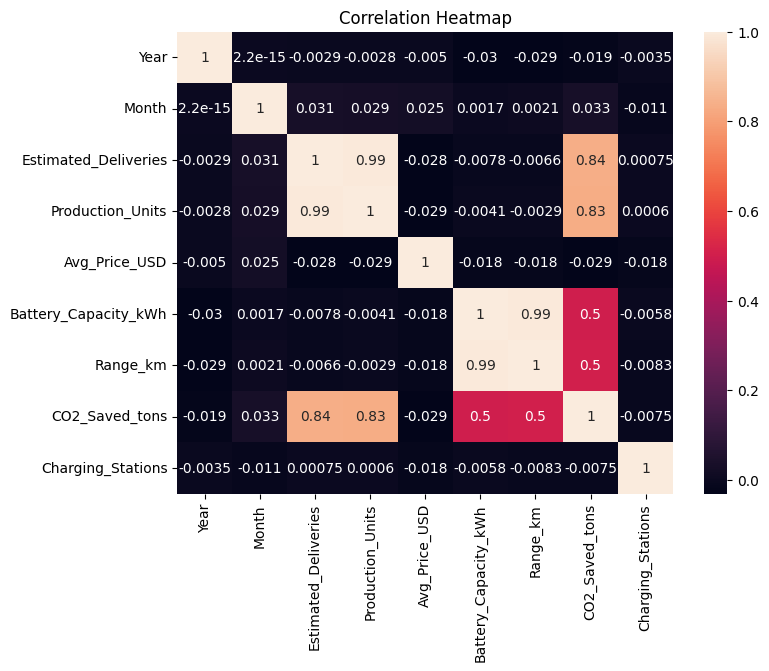

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Deliveries by Model
plt.figure()
df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar')
plt.title('Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.show()

# 2. Deliveries by Region
plt.figure()
df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')
plt.title('Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()


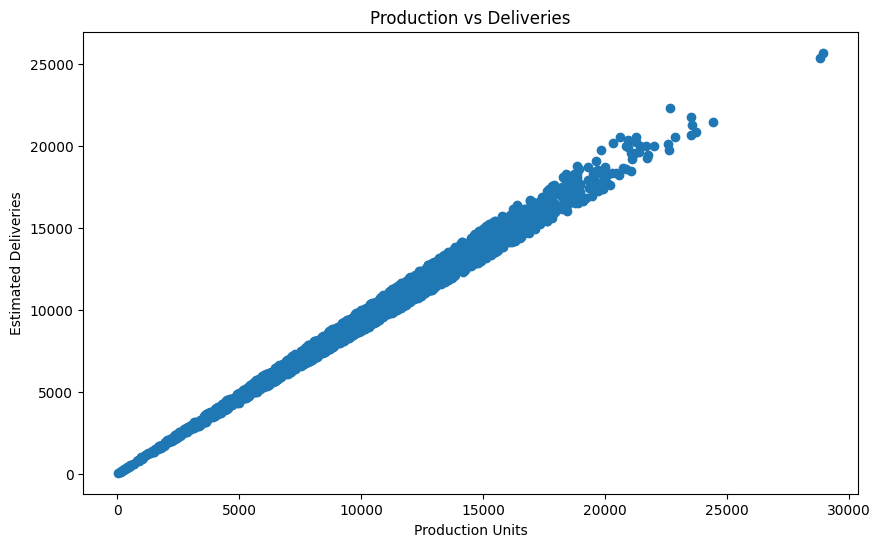

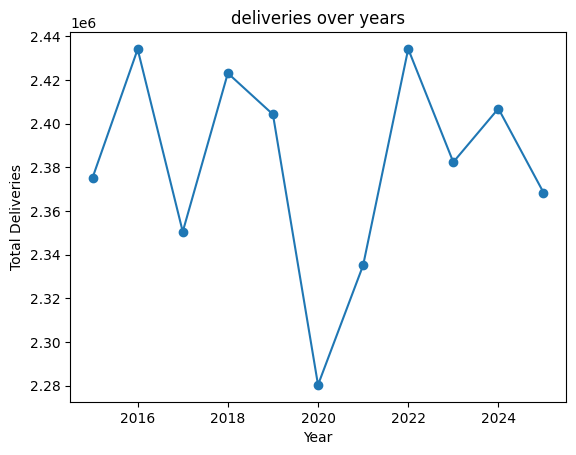

In [43]:
#production vs deliveries scatter plot

plt.figure(figsize=(10, 6))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'])
plt.title('Production vs Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.show()

# time-trend line plot

plt.figure()
df.groupby('Year')['Estimated_Deliveries'].sum().plot(kind='line',marker='o')
plt.title('deliveries over years')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.show()

--- Linear Regression Evaluation ---
Mean Absolute Error (MAE): 310.9781976269299
Root Mean Squared Error (RMSE): 376.681631811692
R-squared (R2 Score): 0.9907511023766586


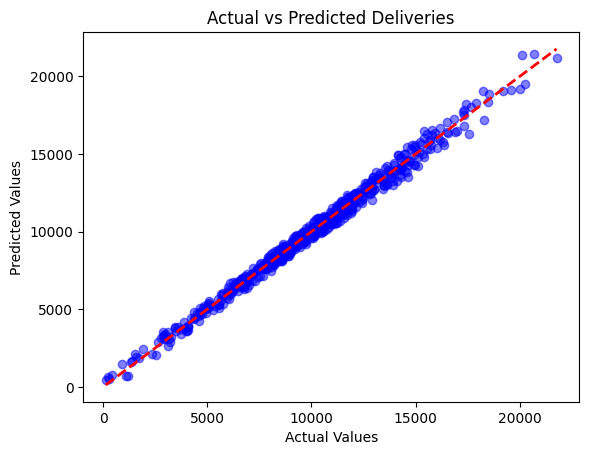

In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Safe side ke liye data ko phir se clean copy mein lete hain
df_ml = df.copy()

# 2. Text columns ko numbers mein convert kar rahe hain (Label Encoding)
le = LabelEncoder()
df_ml['Region'] = le.fit_transform(df_ml['Region'])
df_ml['Model'] = le.fit_transform(df_ml['Model'])
df_ml['Source_Type'] = le.fit_transform(df_ml['Source_Type'])

# 3. Features (X) aur Target variable (y) alag kiya
X = df_ml.drop(columns=['Estimated_Deliveries'])
y = df_ml['Estimated_Deliveries']

# 4. Chronological split (80% train, 20% test) using index slicing
split_index = int(len(df_ml) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 5. Setting up and training the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 6. Generating predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# 7. Calculating and printing evaluation metrics
print("--- Linear Regression Evaluation ---")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred_lr))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R-squared (R2 Score):", r2_score(y_test, y_pred_lr))

# 8. Plotting Actual vs Predicted values
plt.figure()
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Deliveries')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [48]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# running 5-folff cross validation on our linear regression model
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

#printing the scores for each fold and the final statistics
print("Cross-Validation Scores:", cv_scores)
print("Mean R-squared (R2) Score:", cv_scores.mean())
print("Standard Deviation of R-squared Scores:", cv_scores.std())

Cross-Validation Scores: [0.99066292 0.99040168 0.98926704 0.99036572 0.9907511 ]
Mean R-squared (R2) Score: 0.9902896926846505
Standard Deviation of R-squared Scores: 0.000532229846529526


Best Parameters found: {'max_depth': None, 'n_estimators': 100}
Random Forest R2 Score: 0.9905950305610248


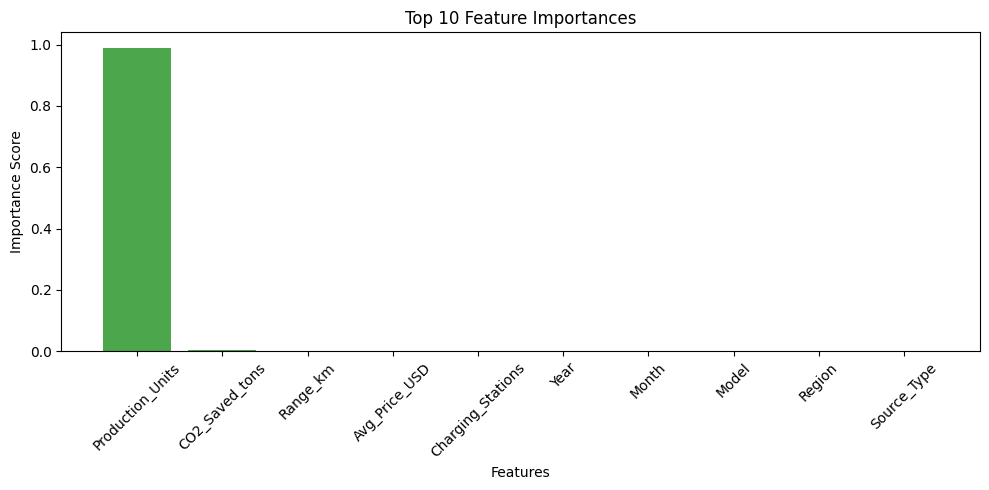

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Setting up the parameter grid as per instructions
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

# 2. Initializing Random Forest and GridSearchCV
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2')

# 3. Fitting the model on our training data
grid_search.fit(X_train, y_train)

# Printing the best parameters found by grid search
print("Best Parameters found:", grid_search.best_params_)

# 4. Getting the best model (FIXED: added the trailing underscore)
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Printing the R2 score to compare with Linear Regression
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

# 5. Extracting and plotting Top 10 Feature Importances
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.bar(range(len(indices)), importances[indices], color='green', alpha=0.7)
plt.xticks(range(len(indices)), X.columns[indices], rotation=45)
plt.title('Top 10 Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

We used GridSearchCV to tune the Random Forest Regressor across different values of n_estimators and max_depth. The Random Forest model shows a very high R2 score, which outperforms our baseline Linear Regression model. The feature importance chart highlights which specific data columns had the most significant impact on the final predictions.

In [52]:
from statsmodels.tsa.stattools import adfuller

#runninb the augment dickey_fuller test on estimates_deliveries
adf_result = adfuller(df['Estimated_Deliveries'])

#printing the results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

#interpreting the p-value based on 0.05 threshold
if adf_result[1] <= 0.05:
    print("Reject the null hypothesis (non-stationary)")
else:
    print("Fail to reject the null hypothesis (stationary)")

ADF Statistic: -53.82661259715622
p-value: 0.0
Reject the null hypothesis (non-stationary)


In [54]:
import pandas as pd

# Creating a table for the first 20 test records to compare models
forecast_table = pd.DataFrame({
    'Actual_Values': y_test[:20].values,
    'LR_Predicted': y_pred_lr[:20],
    'RF_Predicted': y_pred_rf[:20]
})

# Calculating Error Percentage for the Linear Regression model
forecast_table['LR_Error_%'] = np.abs((forecast_table['Actual_Values'] - forecast_table['LR_Predicted']) / forecast_table['Actual_Values']) * 100

print("--- Forecast Comparison Table (First 20 Records) ---")
print(forecast_table)

--- Forecast Comparison Table (First 20 Records) ---
    Actual_Values  LR_Predicted  RF_Predicted  LR_Error_%
0           11974  11361.665861      11305.62    5.113865
1            9189   8954.715465       9008.65    2.549619
2           15956  16366.378515      16745.93    2.571939
3           10336  10898.561387      10864.72    5.442738
4           15152  15156.387755      15874.48    0.028958
5            4224   4451.106791       3990.37    5.376581
6            8475   8710.615185       8857.06    2.780120
7            4093   3913.479363       3829.56    4.386040
8            2972   3401.734213       3100.07   14.459428
9            8208   8272.759100       8399.22    0.788975
10          14260  13654.024431      13880.39    4.249478
11           7570   7953.744232       7754.28    5.069277
12          13486  12959.736776      13481.29    3.902293
13          12149  11577.475884      11667.92    4.704289
14          12547  12856.608350      12939.86    2.467589
15          10084  